pystran - Python package for structural analysis with trusses and beams

(C) 2025, Petr Krysl, pkrysl@ucsd.edu

# Continuous beam with two spans

## Problem description:

Continuous simply supported beam with two spans. The beam is loaded with
moments at the joint.

Displacements and internal forces are provided in the verification manual.

## References

Introductory example 7.1 from Structural Mechanics. Analytical and Numerical
Approaches for Structural Analysis by Lingyi Lu, Junbo Jia, Zhuo Tang.


In [1]:
from numpy import dot
from numpy.linalg import norm
import context
from pystran import model
from pystran import section
from pystran import plots

Create a two dimensional (planar) model.

In [2]:
m = model.create(2)
freedoms = m["freedoms"]

There are three joints.

In [3]:
model.add_joint(m, 1, [0.0, 0.0])
model.add_joint(m, 2, [5.0, 0.0])
model.add_joint(m, 3, [12.0, 0.0])

{'jid': 3, 'coordinates': array([12.,  0.])}

The supports are added to the model. The pinned supports are added to the
joint by listing the degree of freedom designations, `freedoms.U1` and
`freedoms.U2`. These degrees of freedom are suppressed (set to zero).
Note that each of the joints also has a rotation degree of freedom,
`freedoms.UR3`, which are free at all joints.

In [4]:

model.add_support(m["joints"][1], freedoms.U1)
model.add_support(m["joints"][1], freedoms.U2)
model.add_support(m["joints"][2], freedoms.U1)
model.add_support(m["joints"][2], freedoms.U2)
model.add_support(m["joints"][3], freedoms.U1)
model.add_support(m["joints"][3], freedoms.U2)

The beam members have different material properties and different cross sectional
properties. We create two separate sections for the two beam members.


In [5]:
E = 3e10
A = 0.001
I = 1.44e-5
s1 = section.beam_2d_section("section_1", E, A, I)
model.add_beam_member(m, 1, [1, 2], s1)
E = 2.06e11
A = 0.001
I = 1.152e-5
s2 = section.beam_2d_section("section_2", E, A, I)
model.add_beam_member(m, 2, [2, 3], s2)

{'mid': 2,
 'connectivity': [2, 3],
 'section': {'name': 'section_2',
  'E': 206000000000.0,
  'rho': 0.0,
  'CTE': 0.0,
  'A': 0.001,
  'I': 1.152e-05}}

The loads are  moments at the joints.


In [6]:
model.add_load(m["joints"][1], freedoms.UR3, -15e3)
model.add_load(m["joints"][2], freedoms.UR3, -25e3)
model.add_load(m["joints"][3], freedoms.UR3, +35e3)

The model is solved. First we number the degrees of freedom.


In [7]:
model.number_dofs(m)
nt = m["ntotaldof"]
nf = m["nfreedof"]
print("Total Degrees of Freedom = ", nt)
print("Free Degrees of Freedom = ", nf)

Total Degrees of Freedom =  9
Free Degrees of Freedom =  3


Then we call a solver to obtain the static solution.

In [8]:
model.solve_statics(m)

The stiffness matrix for the free degrees of freedom can be printed.


In [9]:
print(m["K"][0:3, 0:3])

[[ 345600.          172800.               0.        ]
 [ 172800.         1701668.57142857  678034.28571429]
 [      0.          678034.28571429 1356068.57142857]]


Here are the calculated free degrees of freedom:


In [10]:
print(m["U"][0:3])

[-0.02969075 -0.02742406  0.03952194]


These displacements can be compared with the reference values from
literature.


In [11]:
if norm(m["U"][0:3] - [-0.02969075, -0.02742406, 0.03952194]) > 1.0e-3:
    raise ValueError("Displacement calculation error")
print("Displacement calculation OK")

Displacement calculation OK


We can calculate the reactions at the supports. This is the manual approach
to that using the partitioning of the stiffness matrix and the displacement
vector.


In [12]:
Kdf = m["K"][nf:nt, 0:nf]
Kdd = m["K"][nf:nt, nf:nt]
Uf = m["U"][0:nf]
Ud = m["U"][nf:nt]

The reactions follow:


In [13]:
R = dot(Kdf, Uf) + dot(Kdd, Ud)
print("Reactions = ", R)

Reactions =  [    0.         -5921.66344294     0.          9437.13733075
     0.         -3515.47388781]


In order to understand moment and shear diagrams, we start by plotting the
geometry with the orientation of the local coordinate system on each beam.


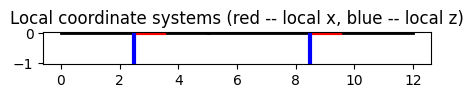

In [14]:
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_member_orientation(m, 1.0)
ax.set_title("Local coordinate systems (red -- local x, blue -- local z)")
plots.show(m)

The deformed shape shows the curvatures of the beam.


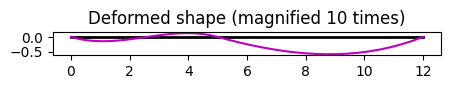

In [15]:
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_deformations(m, 10.0)
ax.set_title("Deformed shape (magnified 10 times)")
plots.show(m)

The bending moment can be compared with the curvature of the beam.


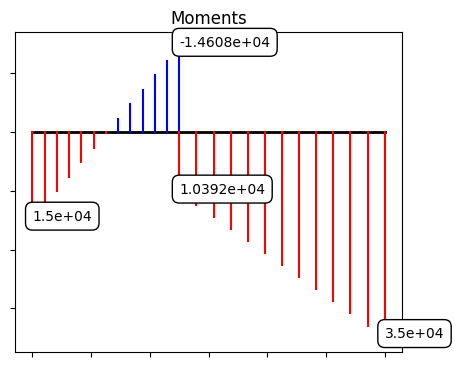

In [16]:
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_bending_moments(m, scale=2e-4)
ax.set_title("Moments")
plots.show(m)

The shear forces are the slopes of the moment diagram.


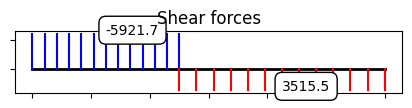

In [17]:
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_shear_forces(m)
ax.set_title("Shear forces")
plots.show(m)

The reaction forces can be plotted after the reactions have been computed (`statics_reactions`).


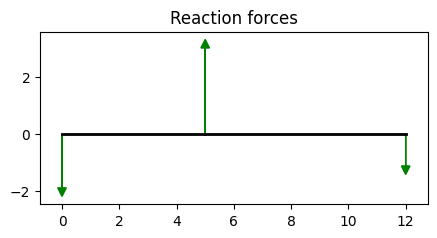

In [18]:
model.statics_reactions(m)
plots.setup(m)
plots.plot_members(m)
ax = plots.plot_reaction_forces(m)
ax.set_title("Reaction forces")
plots.show(m)